In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [24]:
import pandas as pd
df = pd.read_csv("processed/Hostel_Management_Dataset_Cleaned.csv")

In [25]:
df.head()

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,ID_Proof_Type,Aadhaar_Copy,Voter_ID_Copy,Joining_Date,Exit_Date,Bed_Status,Room_Capacity,Available_Beds,Remarks,Age
0,R00001,Resident 1,Male,02-02-1991,800000001,resident1@example.com,1.000000e+11,Infosys,EMP00001,Analyst,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,35
1,R00002,Resident 2,Female,03-03-1992,800000002,resident2@example.com,1.000000e+11,Wipro,EMP00002,Tester,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,34
2,R00003,Resident 3,Male,04-04-1993,800000003,resident3@example.com,1.000000e+11,Accenture,EMP00003,Support Engineer,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,33
3,R00004,Resident 4,Female,05-05-1994,800000004,resident4@example.com,1.000000e+11,Capgemini,EMP00004,Software Engineer,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,1,No Remarks,32
4,R00005,Resident 5,Male,06-06-1995,800000005,resident5@example.com,1.000000e+11,TCS,EMP00005,Analyst,...,Aadhaar,Yes,Yes,01-01-2026,NaN,Occupied,2,0,No Remarks,31


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Resident_ID        10000 non-null  object 
 1   Resident_Name      10000 non-null  object 
 2   Gender             10000 non-null  object 
 3   Date_of_Birth      10000 non-null  object 
 4   Mobile_Number      10000 non-null  int64  
 5   Email              10000 non-null  object 
 6   Aadhaar_Number     10000 non-null  float64
 7   Company_Name       10000 non-null  object 
 8   Employee_ID        10000 non-null  object 
 9   Occupation         10000 non-null  object 
 10  Check_In_Date      10000 non-null  object 
 11  Check_Out_Date     0 non-null      float64
 12  Room_Number        10000 non-null  object 
 13  Bed_Number         10000 non-null  object 
 14  Room_Type          10000 non-null  object 
 15  Floor              10000 non-null  int64  
 16  Monthly_Rent       1000

In [28]:
df.shape

(10000, 44)

In [30]:
df["Date_of_Birth"] = pd.to_datetime(df["Date_of_Birth"], dayfirst=True)
### Create age column ##
df["Date_of_Birth"] = pd.to_datetime(df["Date_of_Birth"])

### Create Age ###
today = pd.Timestamp.today()
df["Age"] = ((today - df["Date_of_Birth"]).dt.days / 365.25).astype(int)
df[["Date_of_Birth","Age"]].head()

,Date_of_Birth,Age
0,1991-02-02,35
1,1992-03-03,34
2,1993-04-04,33
3,1994-05-05,32
4,1995-06-06,31


In [31]:
## AGE outliers analysis(IQR)
Q1 = df["Age"].quantile(0.25)
Q3 = df["Age"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
age_outliers = df[(df["Age"] < lower) | (df["Age"] > upper)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Age Outliers:", len(age_outliers))

Q1: 29.0
Q3: 34.0
IQR: 5.0
Lower Limit: 21.5
Upper Limit: 41.5
Number of Age Outliers: 0


In [32]:
age_outliers

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,ID_Proof_Type,Aadhaar_Copy,Voter_ID_Copy,Joining_Date,Exit_Date,Bed_Status,Room_Capacity,Available_Beds,Remarks,Age


In [33]:
Q1 = df["Deposit_Amount"].quantile(0.25)
Q3 = df["Deposit_Amount"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
deposit_outliers = df[
    (df["Deposit_Amount"] < lower) |
    (df["Deposit_Amount"] > upper)
]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Deposit Outliers:", len(deposit_outliers))

Q1: 10000.0
Q3: 10000.0
IQR: 0.0
Lower Limit: 10000.0
Upper Limit: 10000.0
Number of Deposit Outliers: 0


In [34]:
deposit_outliers

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,ID_Proof_Type,Aadhaar_Copy,Voter_ID_Copy,Joining_Date,Exit_Date,Bed_Status,Room_Capacity,Available_Beds,Remarks,Age


In [35]:
Q1 = df["Amount_Paid"].quantile(0.25)
Q3 = df["Amount_Paid"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
paid_outliers = df[
    (df["Amount_Paid"] < lower) |
    (df["Amount_Paid"] > upper)
]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Number of Amount Paid Outliers:", len(paid_outliers))

Q1: 5750.0
Q3: 9000.0
IQR: 3250.0
Lower Limit: 875.0
Upper Limit: 13875.0
Number of Amount Paid Outliers: 0


In [36]:
paid_outliers

,Resident_ID,Resident_Name,Gender,Date_of_Birth,Mobile_Number,Email,Aadhaar_Number,Company_Name,Employee_ID,Occupation,...,ID_Proof_Type,Aadhaar_Copy,Voter_ID_Copy,Joining_Date,Exit_Date,Bed_Status,Room_Capacity,Available_Beds,Remarks,Age


In [37]:
from scipy.stats import zscore
df["Age_Zscore"] = zscore(df["Age"])
age_z_outliers = df[df["Age_Zscore"].abs() > 3]
print("Number of Age Outliers (Z-score):", len(age_z_outliers))

Number of Age Outliers (Z-score): 0


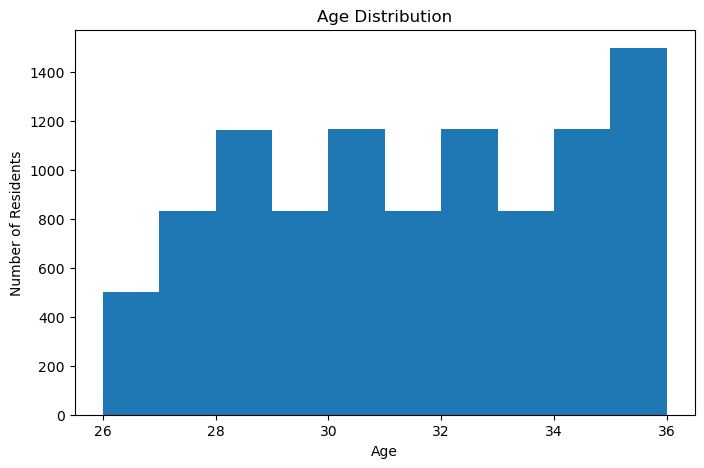

In [38]:
plt.figure(figsize=(8,5))
plt.hist(df["Age"], bins=10)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Residents")
plt.show()

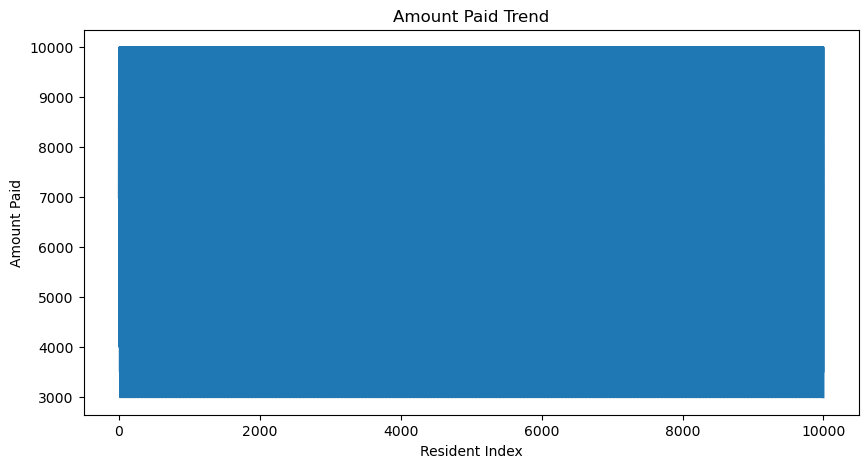

In [39]:
plt.figure(figsize=(10,5))
plt.plot(df.index, df["Amount_Paid"])
plt.title("Amount Paid Trend")
plt.xlabel("Resident Index")
plt.ylabel("Amount Paid")
plt.show()

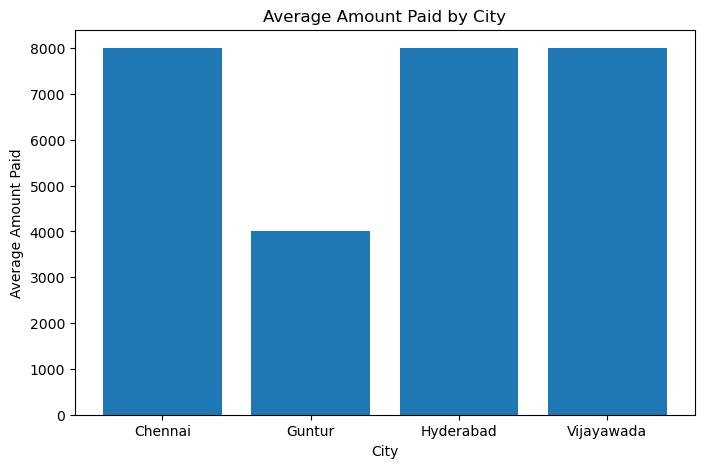

In [40]:
city = df.groupby("City")["Amount_Paid"].mean()
plt.figure(figsize=(8,5))
plt.bar(city.index, city.values)
plt.title("Average Amount Paid by City")
plt.xlabel("City")
plt.ylabel("Average Amount Paid")
plt.show()

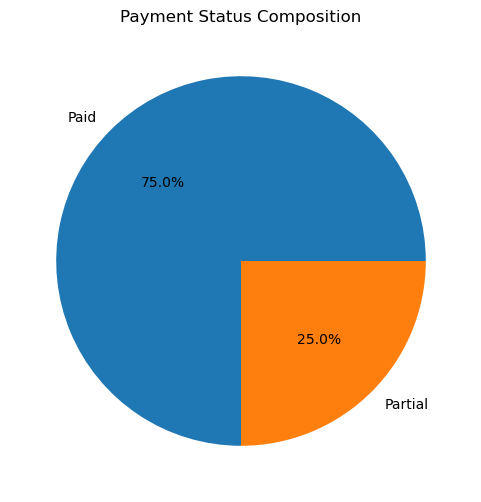

In [41]:
payment = df["Payment_Status"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(payment.values,
        labels=payment.index,
        autopct="%1.1f%%")
plt.title("Payment Status Composition")
plt.show()

# Dataset-Grounded Insights
1. No outliers were detected in the Age column using both the IQR and Z-score methods, indicating a consistent age distribution among residents.
2. Deposit_Amount has no outliers because every resident has the same deposit amount (₹10,000).
3. Amount_Paid shows limited variation, reflecting the payment categories (Paid and Partial).
4. The Payment Status composition indicates that most residents have completed their payments, while a smaller group has partial payments.
5. The city-wise average Amount_Paid varies across cities, suggesting that payment patterns may differ by location.